<a href="https://colab.research.google.com/github/MukulVerma-ML/upskillCampus/blob/main/Crop_Weed_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip -q data.zip -d data

In [ ]:
!find data -type f \( -iname "*.jpg" -o -iname "*.jpeg" -o -iname "*.png" -o -iname "*.txt" \) -exec mv {} data/ \; 2>/dev/null
!ls data | head -5
print("✅ Files moved")

agri_0_1009.jpeg
agri_0_1009.txt
agri_0_1017.jpeg
agri_0_1017.txt
agri_0_1018.jpeg
✅ Files moved


In [ ]:
!pip install split-folders -q
import splitfolders
splitfolders.ratio('data', output='datasets', seed=42, ratio=(.8, .2), move=False)
print("✅ Split done - Check karo")

Copying files: 0 files [00:00, ? files/s]

✅ Split done - Check karo


In [ ]:
import os, shutil, random
from glob import glob

# 1. Saari images nikalo
images = glob('data/*.jpg') + glob('data/*.jpeg') + glob('data/*.png')
random.shuffle(images)

# 2. 80-20 split karo
split_idx = int(0.8 * len(images))
train_imgs = images[:split_idx]
val_imgs = images[split_idx:]

# 3. Folders banao
for split in ['train', 'val']:
    os.makedirs(f'datasets/{split}/images', exist_ok=True)
    os.makedirs(f'datasets/{split}/labels', exist_ok=True)

# 4. Train files copy karo
for img_path in train_imgs:
    img_name = os.path.basename(img_path)
    txt_name = img_name.rsplit('.', 1)[0] + '.txt'
    shutil.copy(img_path, f'datasets/train/images/{img_name}')
    if os.path.exists(f'data/{txt_name}'):
        shutil.copy(f'data/{txt_name}', f'datasets/train/labels/{txt_name}')

# 5. Val files copy karo
for img_path in val_imgs:
    img_name = os.path.basename(img_path)
    txt_name = img_name.rsplit('.', 1)[0] + '.txt'
    shutil.copy(img_path, f'datasets/val/images/{img_name}')
    if os.path.exists(f'data/{txt_name}'):
        shutil.copy(f'data/{txt_name}', f'datasets/val/labels/{txt_name}')

print(f"✅ Split done: {len(train_imgs)} train, {len(val_imgs)} val")

✅ Split done: 1040 train, 260 val


In [ ]:
data_yaml = """
path: /content/datasets
train: train/images
val: val/images

nc: 1
names: ['crop']"""
with open('datasets/data.yaml', 'w') as f:
    f.write(data_yaml)

In [ ]:
!pip install ultralytics -q
from ultralytics import YOLO
model = YOLO('yolov8n.pt')
model.train(data='datasets/data.yaml',epochs=50,imgsz=640,name='crop_final')

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=crop_final-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78676db2e960>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
from ultralytics import YOLO
import glob
from IPython.display import Image, display
import os

# Best model load kar
model = YOLO('runs/detect/crop_final-2/weights/best.pt')

model.val(data='datasets/data.yaml')
# Predict kar val images pe
results = model.predict(
    source='datasets/val/images',
    save=True,
    conf=0.25,
    data='datasets/data.yaml' # <-- Ye line important hai 'object' hatane ke liye
)

print(f"\n✅ Total CROP detect hue: {sum(len(r.boxes) for r in results)}")

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2014.4±575.5 MB/s, size: 63.3 KB)
val: Scanning /content/datasets/val/labels.cache... 260 images, 0 backgrounds, 140 corrupt: 100% ━━━━━━━━━━━━ 260/260 83.9Mit/s 0.0s
val: /content/datasets/val/images/agri_0_1020.jpeg: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible class labels are 0-0
val: /content/datasets/val/images/agri_0_1095.jpeg: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible class labels are 0-0
val: /content/datasets/val/images/agri_0_1146.jpeg: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible class labels are 0-0
val: /content/datasets/val/images/agri_0_1192.jpeg: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible class labels 


📁 Results saved in: /content/runs/detect/predict-3
📸 Total images: 260

agri_0_9439.jpg


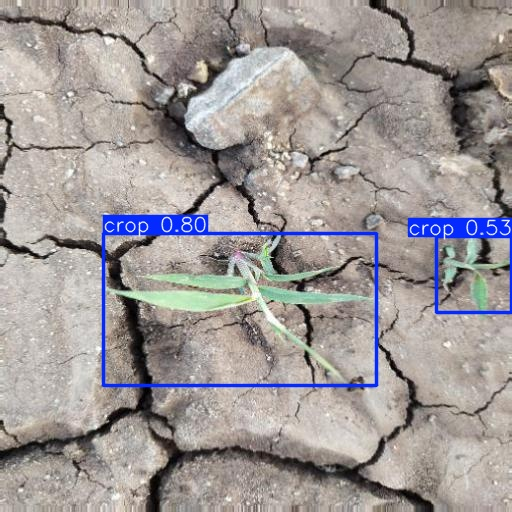


agri_0_8698.jpg


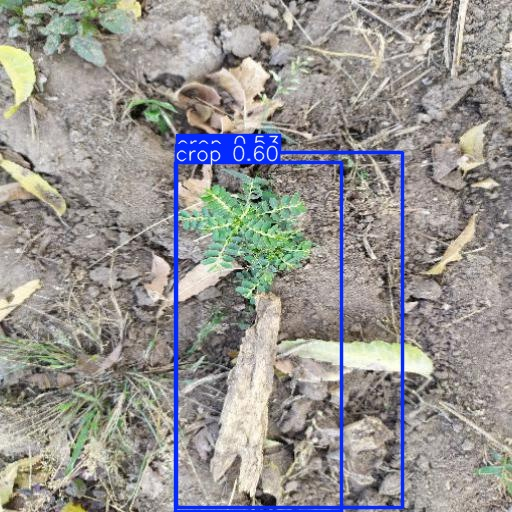


agri_0_9871.jpg


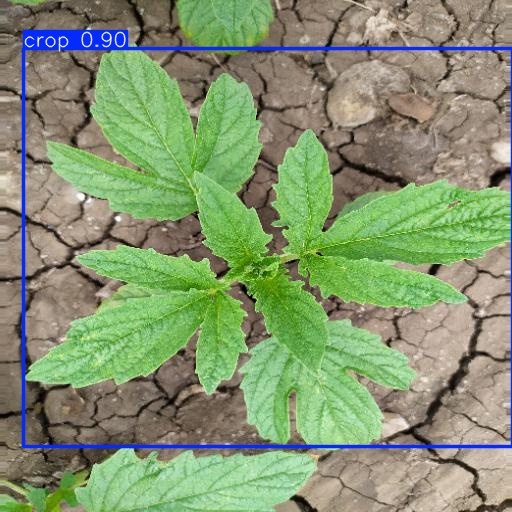


agri_0_7106.jpg


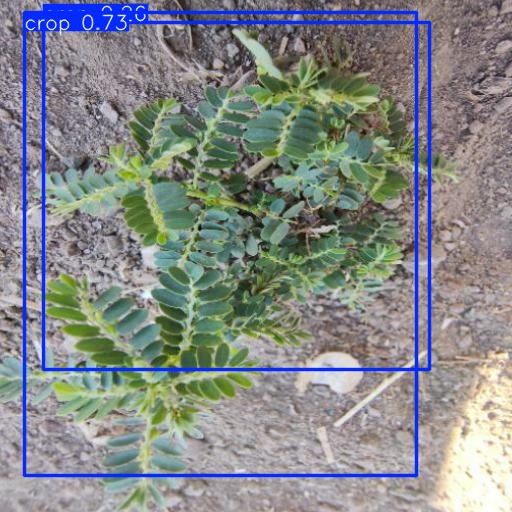


agri_0_6713.jpg


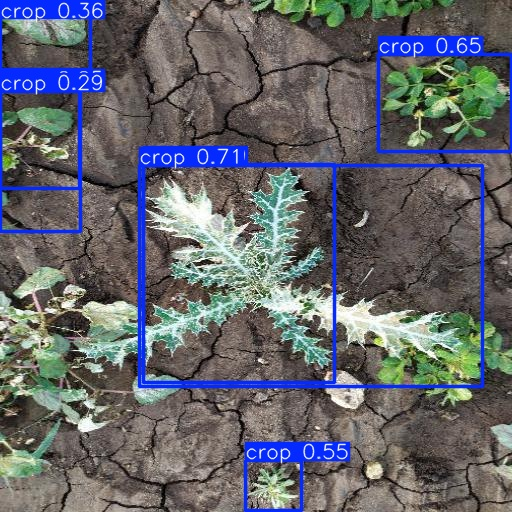


agri_0_567.jpg


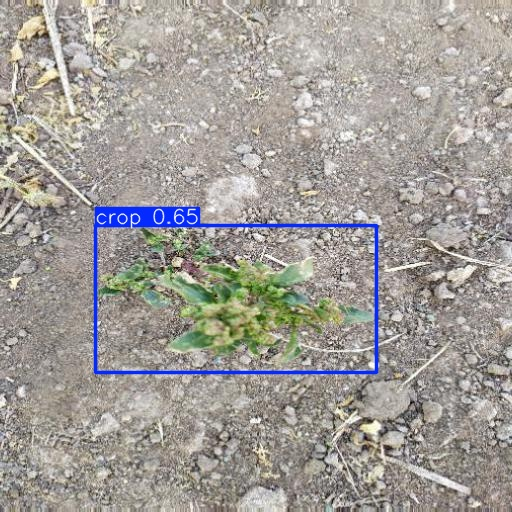


agri_0_1334.jpg


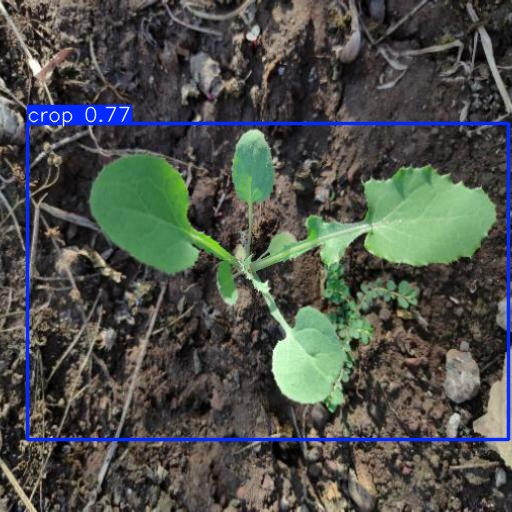


agri_0_8297.jpg


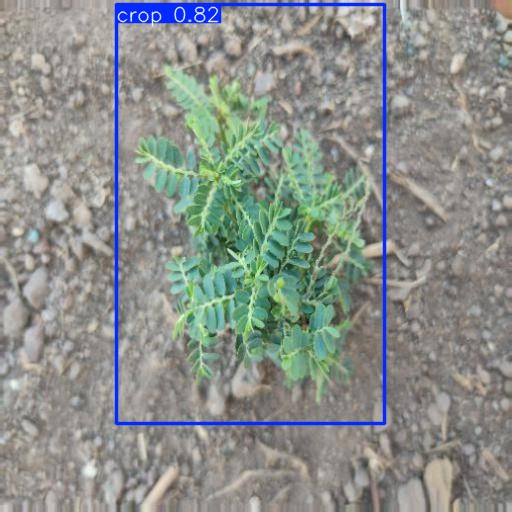


agri_0_401.jpg


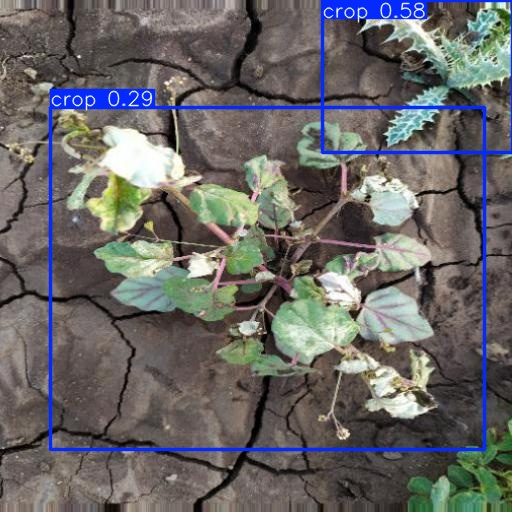


agri_0_3914.jpg


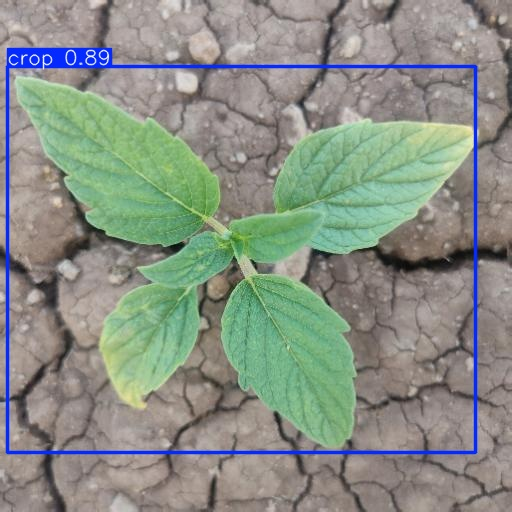

In [ ]:
result_folder = results[0].save_dir
image_paths = glob.glob(f'{result_folder}/*.jpg')

print(f"\n📁 Results saved in: {result_folder}")
print(f"📸 Total images: {len(image_paths)}")

# Pehle 10 image dikha
for img_path in image_paths[:10]:
    print(f"\n{os.path.basename(img_path)}")
    display(Image(img_path, width=350))